# F04 · A notebook is an experiment with state

<!-- paper-first -->
### Research question

**Reading:** [PP01](../../curriculum/papers/processing.md#pp01), [PD01](../../curriculum/papers/design.md#pd01). Review the assigned figure or result before starting the lesson.

**Question:** Which hidden choices would prevent a second analyst from recreating your result?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

<!-- key-references -->
### Why this technique matters

Interactive notebooks execute in temporal kernel order rather than top-to-bottom visual order, allowing out-of-order cell runs, in-place state mutations, and coupled global random seeds to silently invalidate published outputs (Pimentel et al., 2019). Distinguishing bitwise SHA-256 reproducibility, numerical tolerance reproducibility (under IEEE-754 float32 non-associativity and catastrophic cancellation), and scientific replicability is essential for trustworthy neuroimaging workflows (Glatard et al., 2015).

**Key references** · *Jupyter kernel state hygiene, PRNG stream isolation (SeedSequence), IEEE-754 floating-point determinism, and cryptographic provenance*

- *Foundational* — Sandve et al. (2013), [Ten Simple Rules for Reproducible Computational Research](https://doi.org/10.1371/journal.pcbi.1003285), *PLoS Computational Biology*. Establishes foundational practices for tracking execution provenance, software versions, random seeds, and automated end-to-end regeneration of results.
- *Critical evaluation* — Glatard et al. (2015), [Reproducibility of neuroimaging analyses across operating systems](https://doi.org/10.3389/fninf.2015.00012), *Frontiers in Neuroinformatics*. Demonstrates how small IEEE-754 floating-point and math-library differences across operating systems propagate into divergent FreeSurfer and FSL neuroimaging outputs.
- *Critical evaluation* — Pimentel et al. (2019), [A Large-Scale Study About Quality and Reproducibility of Jupyter Notebooks](https://doi.org/10.1109/MSR.2019.00077), *2019 IEEE/ACM 16th International Conference on Mining Software Repositories (MSR)*. Audits over 1.4 million GitHub Jupyter notebooks, showing that out-of-order execution state and missing dependency specifications cause most notebooks to fail reproduction.
- *Review* — Rule et al. (2019), [Ten simple rules for writing and sharing computational analyses in Jupyter Notebooks](https://doi.org/10.1371/journal.pcbi.1007007), *PLOS Computational Biology*. Provides actionable guidelines for cell idempotency, clean top-to-bottom kernel execution, and modular function design in scientific notebooks.

Full entries, verification status and citation counts: [course bibliography](../../curriculum/papers/REFERENCES.md#f04).
<!-- /key-references -->

**Learning format:** predict $\to$ ask AI for one short operation $\to$ run $\to$ inspect $\to$ deliberately break $\to$ explain. Use Goose with a local Ollama model, or ChatGPT as a tutor and snippet writer. You are responsible for deciding whether the transformation answers the research question. Read the answer guide only after making your own prediction.

**Time:** 60–90 minutes. **Prerequisite:** F03 and the [setup guide](../../curriculum/SETUP.md).

---

### 1. Why Interactive Notebooks Fail Silently: Hidden Kernel State & Out-of-Order Execution

A Jupyter notebook weaves prose, executable code cells, and saved visual outputs into a single `.ipynb` JSON document. However, under the hood, a notebook is connected to a **stateful interactive Python kernel** whose in-memory symbol table (`globals()`) evolves in **temporal execution order**, not in visual top-to-bottom page order!

Consider three classic ways interactive notebook state corrupts neuroimaging experiments:
1. **Out-of-Order Cell Execution (`In [1]`, `In [5]`, `In [3]`):** You define `smoothing_fwhm = 6.0` in Cell 2, run Cell 3 to compute a statistical map, then run a later Cell 4 that overwrites `smoothing_fwhm = 12.0`, and re-run Cell 3 without re-running Cell 2. Cell 3 now uses `12.0` while Cell 2 above it still reads `6.0`. Empirical audits of public GitHub repositories show that hidden execution-order state and missing environment specifications cause the vast majority of shared Jupyter notebooks to fail reproduction (Pimentel et al., 2019; Rule et al., 2019).
2. **Deleted-Cell "Zombie" Variables:** You create a filtered array `bold_clean` in a scratch cell, plot it in a later cell, and then delete the scratch cell to "clean up the notebook." The notebook still runs in your current session because `bold_clean` lives in RAM—until a collaborator (or our automated validator `scripts/validate_notebooks.py`) restarts the kernel and crashes with `NameError: name 'bold_clean' is not defined`!
3. **Repeated In-Place Cell Re-Execution:** If Cell 3 contains `data = data - background_offset` or `threshold *= 1.1` (referencing a variable created in Cell 1) and you press `Shift+Enter` on Cell 3 three times while tweaking a plot label, the transformation is applied **three times cumulatively**, even if you later run a lower cell so the execution numbers look sequential!

Therefore, **Restart Kernel and Run All Cells (in a fresh process from top to bottom)** is a mandatory scientific gate—not a cosmetic formatting step.

### 2. The Four-Tier Hierarchy of Computational Reproducibility

Building on reproducible computational research rules (Sandve et al., 2013), cross-platform neuroimaging audits (Glatard et al., 2015), [fMRIPrep (`PP01`)](../../curriculum/papers/processing.md#pp01), and [NARPS (`PD01`)](../../curriculum/papers/design.md#pd01), we must distinguish four distinct levels of reproducibility and replicability:

| Reproducibility Tier | Definition & Verification Criterion | What Breaks It | Does It Prove Biological Truth? |
|---|---|---|---|
| **1. Bitwise Reproducibility** | Identical output bytes (`SHA-256` cryptographic digest match) from identical input bytes, code, seed, and environment. | Different OS/CPU instruction sets (AVX-512 vs. ARM NEON), non-deterministic GPU atomic reductions, library version bumps, `float32` summation order. | **No:** A buggy pipeline reproduces its exact wrong bytes every time! |
| **2. Numerical Tolerance Reproducibility** | Output arrays agree within controlled IEEE-754 floating-point tolerances: $|a - b| \le \text{atol} + \text{rtol}\cdot |b|$ (`np.allclose`). | Catastrophic cancellation, uncompensated `float32` accumulation across long 4D time series, ill-conditioned design matrices (`P02`). | **No:** Verifies numerical stability of the algorithm, not experimental validity. |
| **3. Statistical / PRNG Stream Reproducibility** | Independent pseudorandom number generator objects (`np.random.default_rng(seed)`) produce identical Monte Carlo / bootstrap / permutation distributions. | Relying on legacy global `np.random.seed()`, where adding a single random plot sample in an earlier cell shifts every downstream permutation test! | **No:** Fixes Monte Carlo sampling variance for auditability. |
| **4. Scientific Replicability & Robustness** | Consistent biological conclusions across reasonable analytical specifications (`PD01` multiverse) and independent participant cohorts (`PD02`). | Small sample sizes (`PD02`), scanner batch confounds (`PD07`), circular feature selection (`PD04`), p-hacking / threshold cherry-picking (`PD05`). | **No single study proves biological truth, but this tier provides the strongest empirical support** within the modality's physical measurement limits (`PB01`). |

### 3. IEEE-754 Floating-Point Non-Associativity & `float32` Accumulation Drift in 4D fMRI

Real numbers in pure mathematics obey associativity: $(a + b) + c = a + (b + c)$. **IEEE-754 floating-point numbers do not!** Because `float32` has only 24 bits of significand precision ($\approx 7$ decimal digits, machine epsilon $\epsilon_{\text{mach}} \approx 1.19 \times 10^{-7}$), adding a small temporal fluctuation ($\Delta x \approx 0.5$) to a large running sum of raw scanner baselines ($\sum_{t=1}^T B \approx 2000 \times 1000 = 2 \times 10^6$) loses low-order mantissa bits when accumulated naively in `float32`.

Even worse is the **textbook one-pass variance formula** $\text{Var}(X) = \frac{1}{T}\sum_{t=1}^T X_t^2 - \left(\frac{1}{T}\sum_{t=1}^T X_t\right)^2$ when evaluated in `float32` on raw scanner intensities ($B \approx 50,000$, $\sigma = 1.0$). Squaring $50,000$ produces $2.5 \times 10^9$, which exceeds the 7-digit precision of `float32` so severely that subtracting $(\bar{X})^2$ suffers **catastrophic cancellation**, returning a severely quantized or zero variance (e.g., `0.000000` in Step 3 below, or multiples of `256.0`) instead of `1.0`. Two-pass variance $\frac{1}{T}\sum (X_t - \bar{X})^2$ or accumulating in `float64` (`dtype=np.float64`) eliminates this numerical failure immediately.

### 4. Repository Architecture & Provenance Boundaries

To prevent ambiguity about what has been executed and verified in this repository, we enforce three strict provenance tiers:
- **Core Offline Notebooks (`execution_tier: "offline"`):** Generate controlled synthetic data internally or use the local Nilearn MNI152 template (`P01`), and are executed in fresh isolated kernels by `scripts/validate_notebooks.py`.
- **Network Project (`P02`, `execution_tier: "network"`):** Downloads the public UCL SPM auditory teaching dataset into ignored `data/` and writes provenance summaries to `outputs/P02/`.
- **Third-Party Reference Copies (`third_party/`):** Byte-verified against upstream `SHA-256` manifests by `scripts/check_repository.py` and never silently modified or claimed as our own executed code.

Ask AI: **“Give a minimal environment report without printing environment variables or credentials. Explain which checks demonstrate bitwise vs. numerical reproducibility and which cannot prove scientific validity.”**


### Step 1 · Record the Environment Without Leaking Secrets

A reproducible provenance manifest records the exact Python interpreter version and package versions (`importlib.metadata`), **never** `os.environ` (which can expose API keys, tokens, or private local paths in saved notebook outputs).


In [1]:
import sys, json, importlib.metadata as metadata

packages = ['numpy', 'scipy', 'pandas', 'scikit-learn', 'nibabel', 'nilearn', 'nbformat']
versions = {name: metadata.version(name) for name in packages}
print('Python:', sys.version.split()[0])
print(json.dumps(versions, indent=2))
assert all(versions.values())


Python: 3.12.14
{
  "numpy": "2.5.3",
  "scipy": "1.18.1",
  "pandas": "3.0.6",
  "scikit-learn": "1.9.1",
  "nibabel": "5.4.2",
  "nilearn": "0.14.1",
  "nbformat": "5.11.1"
}


### Step 2 · PRNG Stream Isolation (`default_rng`) and Cryptographic Byte Hashing (`SHA-256`)

Predict whether calling `experiment(104)` twice produces the exact same 64-character `SHA-256` hex digest, and why passing an explicit `np.random.default_rng(seed)` object (or spawning independent child streams via `np.random.SeedSequence(seed).spawn(k)`) is safer than relying on legacy global `np.random.seed()` state when helper functions draw random numbers.


In [2]:
import numpy as np, hashlib

def experiment(seed):
    data = np.random.default_rng(seed).normal(size=100)
    return data.mean(), hashlib.sha256(data.tobytes()).hexdigest()

a, b, c = experiment(104), experiment(104), experiment(105)
assert a == b and a != c
print('Repeated seed agrees:', a == b)
print('Mean:', float(a[0]), 'array SHA-256:', a[1])

# Contrast isolated Generator streams vs. legacy global np.random state coupling
def global_stream_simulation(intervene=False):
    np.random.seed(2026)
    subj_effect = np.random.normal(loc=0.5, scale=1.0, size=50)
    if intervene:
        _ = np.random.uniform(size=7)  # E.g., an extra random jitter plot added in a cell!
    perm_null = np.random.normal(loc=0.0, scale=1.0, size=50)
    return float(perm_null.mean())

def isolated_stream_simulation(intervene=False):
    ss = np.random.SeedSequence(2026)
    rng_subj, rng_plot, rng_perm = [np.random.default_rng(s) for s in ss.spawn(3)]
    subj_effect = rng_subj.normal(loc=0.5, scale=1.0, size=50)
    if intervene:
        _ = rng_plot.uniform(size=7)  # Draws from rng_plot; rng_perm is 100% untouched!
    perm_null = rng_perm.normal(loc=0.0, scale=1.0, size=50)
    return float(perm_null.mean())

assert global_stream_simulation(False) != global_stream_simulation(True)
assert isolated_stream_simulation(False) == isolated_stream_simulation(True)
print('Global PRNG shifted by extra plot draw:', global_stream_simulation(False) != global_stream_simulation(True))
print('Spawned SeedSequence isolated from extra plot draw:', isolated_stream_simulation(False) == isolated_stream_simulation(True))


Repeated seed agrees: True
Mean: 0.1464256175729424 array SHA-256: 6fc6b0f909e49799e132396c69d59b16719eaf5e2c6b6cc74cf8ce6e18bb2e1e
Global PRNG shifted by extra plot draw: True
Spawned SeedSequence isolated from extra plot draw: True


### Step 3 · Simulating Hidden Kernel State Corruption & IEEE-754 `float32` vs. `float64` Drift

Let us now test two subtle computational failures:
1. **Stateful In-Place Re-Execution Bug:** Suppose a notebook stores a mutable dictionary or array `state['bold']` and a cell applies baseline normalization + scaling in place. Running that cell once in a clean top-to-bottom run vs. running it twice interactively changes the downstream ROI effect estimate and invalidates the saved output hash!
2. **IEEE-754 Floating-Point Non-Associativity & `float32` Accumulation Error:** We simulate a long high-baseline fMRI time series ($T = 4,096$ time points, baseline $= 50,000.0$, task fluctuation $\sigma = 1.0$) and compare the textbook one-pass `float32` variance formula against two-pass `float64` accumulation, plus forward vs. sorted `float32` summation order.


In [3]:
# 1. Simulate clean top-to-bottom execution vs. interactive re-execution of a stateful cell
def make_initial_state(seed=404):
    rng_local = np.random.default_rng(seed)
    t_ax = np.linspace(0, 6 * np.pi, 120)
    signal_raw = 500.0 + 4.0 * np.sin(t_ax) + rng_local.normal(0, 1.5, size=120)
    return {'bold': signal_raw.copy(), 't_ax': t_ax, 'steps_run': 0}

def stateful_cell_operation(state_dict, highpass_Strength=0.15):
    '''Anti-pattern: mutates state_dict['bold'] in place without idempotency guard!'''
    s = state_dict['bold']
    # Subtract a moving trend and scale in place
    trend = highpass_Strength * np.cos(state_dict['t_ax']) * (s.std() + 1.0)
    state_dict['bold'] = (s - trend) * 0.92
    state_dict['steps_run'] += 1
    return state_dict['bold']

clean_state = make_initial_state()
clean_series = stateful_cell_operation(clean_state).copy()  # Executed once (top-to-bottom)

dirty_state = make_initial_state()
_ = stateful_cell_operation(dirty_state)
dirty_series = stateful_cell_operation(dirty_state).copy()  # Executed twice interactively!

assert not np.allclose(clean_series, dirty_series)

# 2. IEEE-754 Floating-Point Non-Associativity & float32 vs float64 Temporal Variance Drift
rng_fp = np.random.default_rng(1234)
T_long = 4096
# Large static scanner offset (50,000 ADC units) + small unit-variance BOLD fluctuations
fluct_f64 = rng_fp.normal(0.0, 1.0, size=T_long).astype(np.float64)
fluct_f64 -= fluct_f64.mean()  # Exact zero mean in float64
series_f64 = 50000.0 + fluct_f64
series_f32 = series_f64.astype(np.float32)

# Textbook one-pass variance formula E[X^2] - (E[X])^2 in float32 vs two-pass float64 variance
var_true_f64 = float(np.var(series_f64, dtype=np.float64))
var_onepass_f32 = float(np.mean(series_f32 ** 2, dtype=np.float32) - (np.mean(series_f32, dtype=np.float32) ** 2))
var_twopass_f64 = float(np.var(series_f32, dtype=np.float64))

# Non-associativity check: summing in original order vs sorted order in float32
sum_forward_f32 = float(np.sum(fluct_f64.astype(np.float32), dtype=np.float32))
sum_sorted_f32 = float(np.sum(np.sort(fluct_f64.astype(np.float32)), dtype=np.float32))
assert sum_forward_f32 != sum_sorted_f32
print(f"True variance (f64): {var_true_f64:.6f} | One-pass float32 variance (catastrophic cancellation!): {var_onepass_f32:.6f} | Two-pass f64: {var_twopass_f64:.6f}")
print(f"float32 summation order discrepancy: |forward - sorted| = {abs(sum_forward_f32 - sum_sorted_f32):.6e}")


True variance (f64): 1.006393 | One-pass float32 variance (catastrophic cancellation!): 0.000000 | Two-pass f64: 1.006401
float32 summation order discrepancy: |forward - sorted| = 3.814697e-06


### Step 4 · Visual Reproducibility Dashboard: State Corruption, PRNG Coupling, and Precision Drift

Let us plot a 2x2 diagnostic dashboard summarizing our four reproducibility audits across pipeline execution:
- **Panel A (Hidden Kernel State Corruption):** Compares a clean top-to-bottom execution (`steps_run == 1`) against an interactive session where a stateful cell was executed twice (`steps_run == 2`), demonstrating how in-place mutation shifts both baseline amplitude and temporal phase without raising any warning.
- **Panel B (PRNG Stream Coupling vs. Spawned Child Isolation):** Across $30$ independent simulation seeds, adding a single 5-element random uniform draw for an upstream plot jitter shifts every downstream permutation mean under legacy `np.random.seed()`, whereas `SeedSequence(s_idx).spawn(2)` maintains exact `0.0` drift across all $30$ seeds.
- **Panel C (Catastrophic Cancellation in `float32` One-Pass Variance):** Plots absolute variance error on a log-log scale as the static scanner baseline offset increases from $10^2$ to $10^5$ ADC units, contrasting the breakdown of naive one-pass `float32` ($E[X^2] - E[X]^2$) against a two-pass `float64` accumulator.
- **Panel D (Bitwise `SHA-256` vs. Numerical `np.allclose` Audit Matrix):** Schematic summary of the Step 2–3 audits distinguishing harmless floating-point reduction re-ordering (which fails bitwise `SHA-256` but passes numerical tolerance checks) and isolated-stream upstream plot edits from stateful cell re-execution (which fails both).


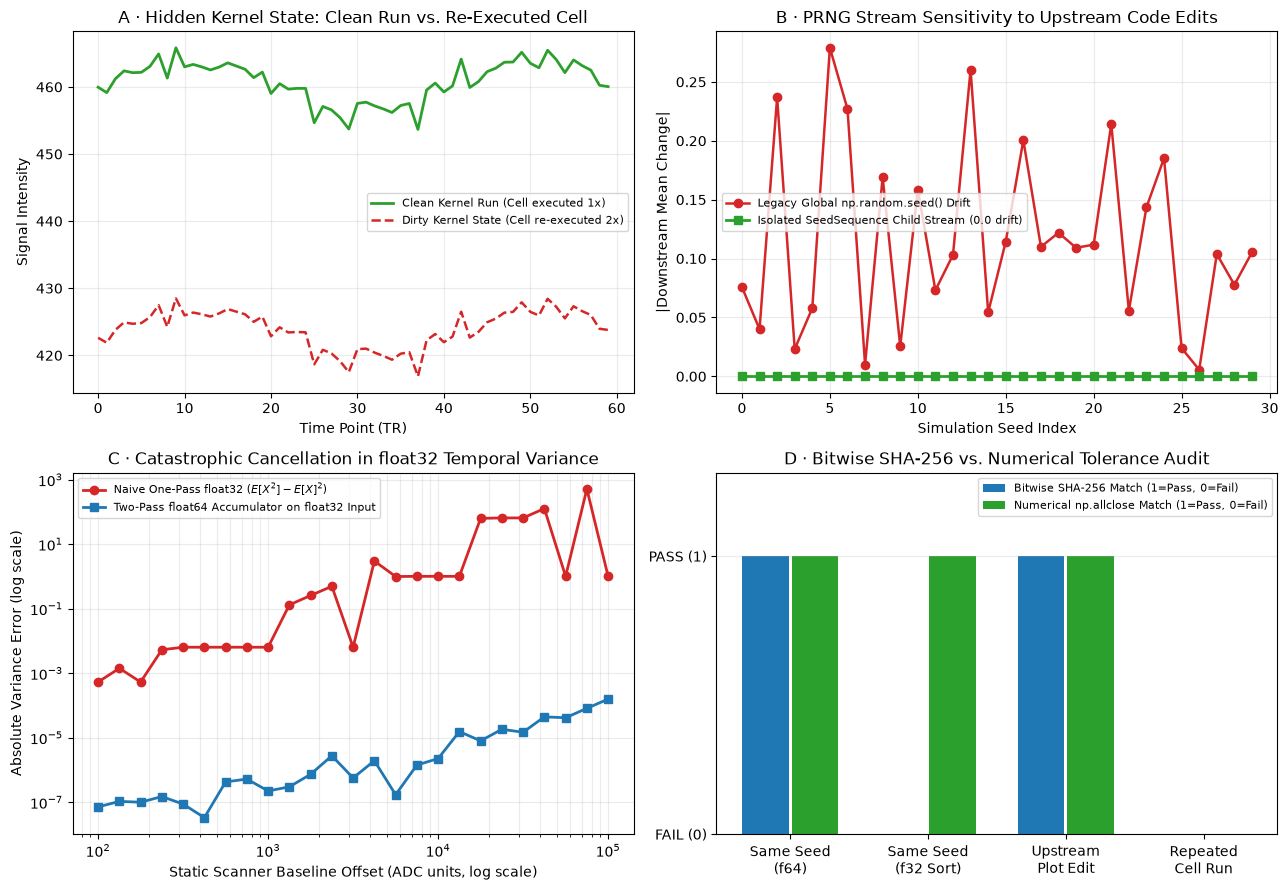

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel A: Clean top-to-bottom run vs. interactive out-of-order / repeated cell execution
ax = axes[0, 0]
ax.plot(clean_series[:60], color='#2ca02c', lw=2, label='Clean Kernel Run (Cell executed 1x)')
ax.plot(dirty_series[:60], color='#d62728', lw=1.8, ls='--', label='Dirty Kernel State (Cell re-executed 2x)')
ax.set_title('A · Hidden Kernel State: Clean Run vs. Re-Executed Cell')
ax.set_xlabel('Time Point (TR)')
ax.set_ylabel('Signal Intensity')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# Panel B: Global PRNG state coupling vs. Spawned SeedSequence across 30 Monte Carlo trials
ax = axes[0, 1]
n_mc = 30
global_diffs, isolated_diffs = [], []
for s_idx in range(100, 100 + n_mc):
    np.random.seed(s_idx)
    _ = np.random.normal(size=20)
    g1 = np.random.normal(size=50).mean()
    np.random.seed(s_idx)
    _ = np.random.normal(size=20)
    _ = np.random.uniform(size=5)  # Upstream cell perturbation
    g2 = np.random.normal(size=50).mean()
    global_diffs.append(abs(g1 - g2))

    seq1 = np.random.SeedSequence(s_idx).spawn(2)
    i1 = np.random.default_rng(seq1[1]).normal(size=50).mean()
    seq2 = np.random.SeedSequence(s_idx).spawn(2)
    _ = np.random.default_rng(seq2[0]).uniform(size=5)  # Upstream perturbation isolated to child 0
    i2 = np.random.default_rng(seq2[1]).normal(size=50).mean()
    isolated_diffs.append(abs(i1 - i2))

ax.plot(range(n_mc), global_diffs, 'o-', color='#d62728', lw=1.8, label='Legacy Global np.random.seed() Drift')
ax.plot(range(n_mc), isolated_diffs, 's-', color='#2ca02c', lw=2, label='Isolated SeedSequence Child Stream (0.0 drift)')
ax.set_title('B · PRNG Stream Sensitivity to Upstream Code Edits')
ax.set_xlabel('Simulation Seed Index')
ax.set_ylabel('|Downstream Mean Change|')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# Panel C: IEEE-754 float32 one-pass variance error vs. Baseline Offset Magnitude
ax = axes[1, 0]
offsets = np.logspace(2, 5, 25)
f32_onepass_errs, f64_twopass_errs = [], []
for off in offsets:
    s64 = off + fluct_f64
    s32 = s64.astype(np.float32)
    v_ref = float(np.var(s64, dtype=np.float64))
    v_f32_1p = float(np.mean(s32 ** 2, dtype=np.float32) - (np.mean(s32, dtype=np.float32) ** 2))
    v_f64_2p = float(np.var(s32, dtype=np.float64))
    f32_onepass_errs.append(abs(v_f32_1p - v_ref) + 1e-12)
    f64_twopass_errs.append(abs(v_f64_2p - v_ref) + 1e-12)

ax.loglog(offsets, f32_onepass_errs, 'o-', color='#d62728', lw=2, label=r'Naive One-Pass float32 ($E[X^2] - E[X]^2$)')
ax.loglog(offsets, f64_twopass_errs, 's-', color='#1f77b4', lw=2, label='Two-Pass float64 Accumulator on float32 Input')
ax.set_title('C · Catastrophic Cancellation in float32 Temporal Variance')
ax.set_xlabel('Static Scanner Baseline Offset (ADC units, log scale)')
ax.set_ylabel('Absolute Variance Error (log scale)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25, which='both')

# Panel D: Reproducibility Audit Matrix across Pipeline Stages
ax = axes[1, 1]
stages = ['Same Seed\n(f64)', 'Same Seed\n(f32 Sort)', 'Upstream\nPlot Edit', 'Repeated\nCell Run']
bit_ident = [1.0, 0.0, 1.0, 0.0]
num_close = [1.0, 1.0, 1.0, 0.0]
x_pos = np.arange(len(stages))
ax.bar(x_pos - 0.18, bit_ident, width=0.34, color='#1f77b4', label='Bitwise SHA-256 Match (1=Pass, 0=Fail)')
ax.bar(x_pos + 0.18, num_close, width=0.34, color='#2ca02c', label='Numerical np.allclose Match (1=Pass, 0=Fail)')
ax.set_xticks(x_pos)
ax.set_xticklabels(stages)
ax.set_yticks([0, 1])
ax.set_yticklabels(['FAIL (0)', 'PASS (1)'])
ax.set_ylim(0, 1.3)
ax.set_title('D · Bitwise SHA-256 vs. Numerical Tolerance Audit')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.show()


## Explain without AI

1. **Execution Counts vs. Clean State:** Restart the kernel and run all cells from top to bottom. Explain why seeing consecutive execution counts (`In [1]`, `In [2]`, `In [3]`, `In [4]`) in a saved `.ipynb` file is **not** sufficient proof that the notebook ran cleanly from a fresh kernel without hidden state mutations.
2. **Bitwise (`SHA-256`) vs. Numerical (`np.allclose`) vs. Scientific Validity:** Using Step 3 and Panel C–D, explain why changing summation order in `float32` breaks a `SHA-256` byte hash while passing `np.allclose`, and why a notebook that passes both `SHA-256` and `np.allclose` checks can still be scientifically invalid (`PD01`, `PP01`).
3. **Global Seed Coupling:** Why did adding a 5-element random uniform draw for a plot jitter in Panel B alter the downstream permutation distribution under `np.random.seed(s_idx)`, and how does `SeedSequence.spawn()` prevent this coupling?
4. **Offline vs. External Provenance:** Identify two external resources in the wider course repository that this offline foundational notebook does **not** execute or certify, and explain how each is audited in the course workflow.

<details><summary>Answer guide</summary>

1. **Consecutive Execution Count Illusion:** A user can run Cell 1 (`In [1]`), run a scratch Cell 99 (`In [2]`, which mutates a global dictionary or sets a global parameter), delete Cell 99, and then run Cell 2 (`In [3]`) and Cell 3 (`In [4]`)—or edit Cell 1's source code *after* running it without re-executing! Only a fresh headless run (`nbclient` / `Restart & Run All`) guarantees that the saved outputs correspond to the visible top-to-bottom source code.
2. **Bitwise vs. Numerical vs. Scientific:** Floating-point addition is non-associative, so reordering a `float32` reduction alters the least-significant mantissa bits (producing the `3.81e-6` discrepancy in Step 3 that changes the `SHA-256` digest while passing a `1e-5` numerical tolerance check such as `np.allclose(..., atol=1e-5)`). Moreover, `SHA-256` only certifies that *the same bytes were produced*—if a pipeline has an inverted affine matrix or leaks test labels, it will reproducibly generate the exact same wrong answer every time.
3. **PRNG Stream Isolation:** `np.random.seed()` initializes a single global legacy Mersenne Twister (`MT19937`) state shared by every `np.random.*` call. Consuming 5 extra uniform `float64` draws advances the shared global state (by 10 `uint32` words) for all subsequent cells. Spawning independent `default_rng` child streams via `SeedSequence.spawn()` isolates each module's random draws so upstream visualization edits never perturb downstream statistical inference.
4. **External Resources Not Certified Here:** (a) The network-tier `P02` public UCL SPM auditory fMRI dataset download (`fetch_spm_auditory`), which requires network access and writes explicit artifact summaries to `outputs/P02/`, and (b) preserved upstream third-party reference notebooks in `third_party/`, which are byte-hash verified against `SHA-256` manifests by `scripts/check_repository.py` rather than executed in our offline CI.

</details>

**Submission:** Record the input, operation, parameters, output, one preserved property, one lost property, and the evidence that would make you reject the result. Include the prompt and any corrections you made to the generated code. A saved answer is not evidence of understanding until you can defend it orally.


### Return to the research question

Revisit [PP01](../../curriculum/papers/processing.md#pp01), [PD01](../../curriculum/papers/design.md#pd01) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
